# EDA: multi_task_neat_vs_haneat_mjx_backend_v2

Exploratory analysis of the MJX backend experiment grid. Covers:
1. **Run summary** — all finished runs, key hyperparameters, final `best_fitness`
2. **Fitness trajectories** — `fitness/max` over generations, grouped by hyperparameter
3. **Hyperparameter grid** — effect of `algorithm_type × pop_size × compatibility_disjoint` on best fitness
4. **Per-task breakdown** — hopper vs walker2d normalized fitness over time
5. **Structural complexity** — nodes, connections, species count over time and vs final fitness
6. **Stagnation analysis** — how often and when runs stagnate


In [1]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
DB_PATH = Path('../mlflow.db').resolve()
EXPERIMENT_NAME = 'multi_task_neat_vs_haneat_mjx_backend_v2'

mlflow.set_tracking_uri(f'sqlite:///{DB_PATH}')
client = mlflow.tracking.MlflowClient()

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f'MLflow DB: {DB_PATH}')
print(f'DB exists: {DB_PATH.exists()}')

MLflow DB: /Users/svengoerdes/Projects/Thesisv2/tensorneat/mlflow.db
DB exists: True


In [2]:
# ── Load runs ─────────────────────────────────────────────────────────────────
exp = client.get_experiment_by_name(EXPERIMENT_NAME)
assert exp is not None, f'Experiment "{EXPERIMENT_NAME}" not found'

all_runs = client.search_runs(exp.experiment_id, max_results=200)
print(f'Total runs in MLflow: {len(all_runs)}')

rows = []
for r in all_runs:
    p = r.data.params
    m = r.data.metrics
    rows.append({
        'run_id':        r.info.run_id,
        'run_name':      r.info.run_name,
        'status':        r.info.status,
        'algorithm':     p.get('algorithm_type', '?'),
        'pop_size':      int(p.get('pop_size', 0)),
        'disjoint':      float(p.get('compatibility_disjoint', 1.0)),
        'seed':          int(p.get('seed', 0)),
        'best_fitness':  m.get('best_fitness', float('nan')),
    })

summary = pd.DataFrame(rows)
# Each run_id is unique. run_name is NOT unique — it omits compatibility_disjoint,
# so disjoint=0.5 and disjoint=1.0 runs share the same run_name.
# Drop only true run_id duplicates (shouldn't happen, but just in case).
summary = (
    summary
    .drop_duplicates(subset='run_id', keep='first')
    .sort_values(['algorithm', 'pop_size', 'disjoint', 'seed'])
    .reset_index(drop=True)
)

finished = summary[summary['status'] == 'FINISHED'].copy()
print(f'Unique runs: {len(summary)}  |  Finished: {len(finished)}  |  Running: {len(summary[summary["status"] == "RUNNING"])}')
summary[['run_name', 'status', 'algorithm', 'pop_size', 'disjoint', 'seed', 'best_fitness']]

Total runs in MLflow: 16
Unique runs: 16  |  Finished: 16  |  Running: 0


,run_name,status,algorithm,pop_size,disjoint,seed,best_fitness
0,ha_neat_normalized_min_pop1024_gen500_seed42,FINISHED,ha_neat,1024,0.5,42,0.372971
1,ha_neat_normalized_min_pop1024_gen500_seed123,FINISHED,ha_neat,1024,0.5,123,0.361767
2,ha_neat_normalized_min_pop1024_gen500_seed42,FINISHED,ha_neat,1024,1.0,42,0.350010
3,ha_neat_normalized_min_pop1024_gen500_seed123,FINISHED,ha_neat,1024,1.0,123,0.353856
4,ha_neat_normalized_min_pop2048_gen500_seed42,FINISHED,ha_neat,2048,0.5,42,0.407045
5,ha_neat_normalized_min_pop2048_gen500_seed123,FINISHED,ha_neat,2048,0.5,123,0.415574
6,ha_neat_normalized_min_pop2048_gen500_seed42,FINISHED,ha_neat,2048,1.0,42,0.350096
7,ha_neat_normalized_min_pop2048_gen500_seed123,FINISHED,ha_neat,2048,1.0,123,0.397144
8,neat_normalized_min_pop1024_gen500_seed42,FINISHED,neat,1024,0.5,42,0.353987
9,neat_normalized_min_pop1024_gen500_seed123,FINISHED,neat,1024,0.5,123,0.371127


---
## 1 · Fitness Trajectories — `fitness/max` over generations

In [3]:
def load_metric_history(run_id: str, metric: str) -> pd.DataFrame:
    """Return a DataFrame with columns [step, value] for one metric of one run."""
    history = client.get_metric_history(run_id, metric)
    if not history:
        return pd.DataFrame(columns=['step', 'value'])
    return pd.DataFrame({'step': [m.step for m in history],
                         'value': [m.value for m in history]})


def load_all_histories(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Load metric history for all runs in df, return long-format DataFrame."""
    parts = []
    for _, row in df.iterrows():
        hist = load_metric_history(row['run_id'], metric)
        if hist.empty:
            continue
        hist['run_id']    = row['run_id']
        hist['run_name']  = row['run_name']
        hist['algorithm'] = row['algorithm']
        hist['pop_size']  = row['pop_size']
        hist['disjoint']  = row['disjoint']
        hist['seed']      = row['seed']
        hist['label'] = (
            f"{row['algorithm']} pop={row['pop_size']} "
            f"disj={row['disjoint']} s={row['seed']}"
        )
        parts.append(hist)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

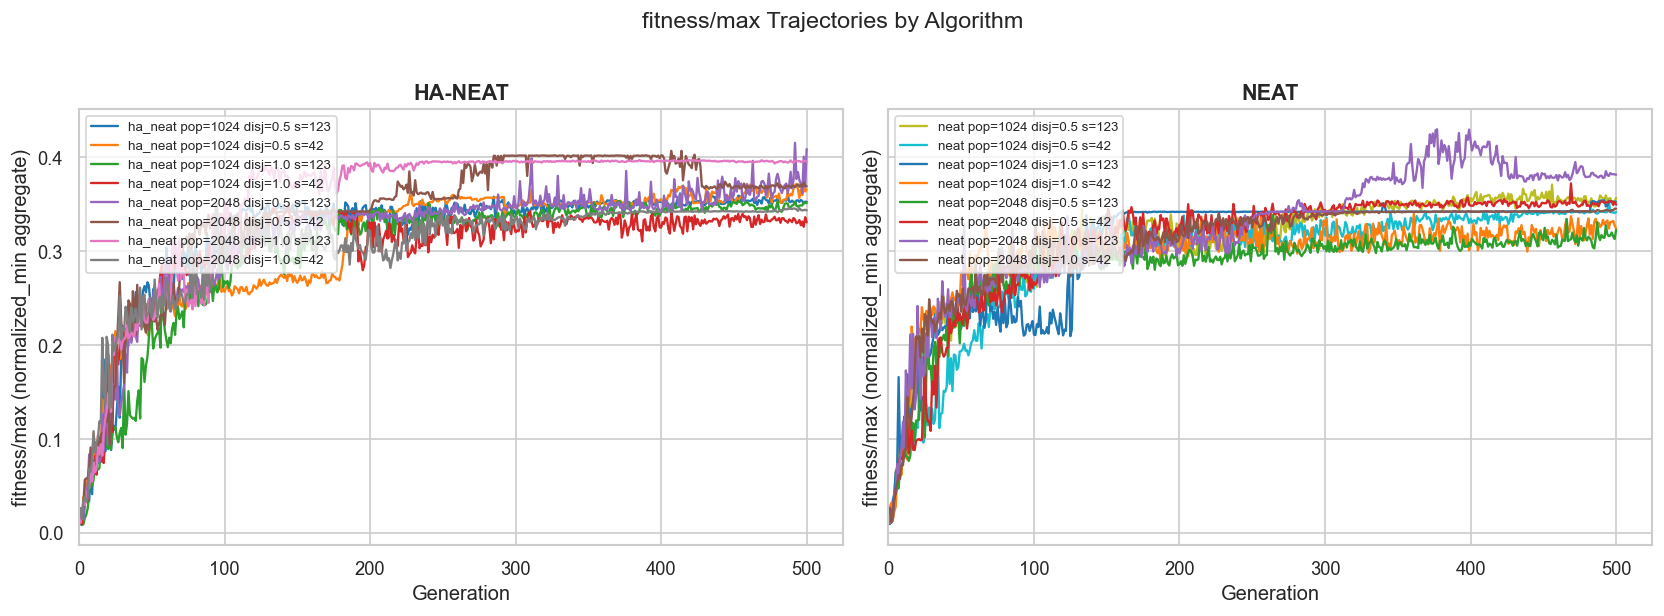

In [4]:
# Load fitness/max history for all finished runs
fit_hist = load_all_histories(finished, 'fitness/max')

# ── Plot: one panel per algorithm, lines coloured by (pop_size, disjoint, seed) ──
algos = sorted(fit_hist['algorithm'].unique())
fig, axes = plt.subplots(1, len(algos), figsize=(7 * len(algos), 5), sharey=True)
if len(algos) == 1:
    axes = [axes]

palette = sns.color_palette('tab10', n_colors=fit_hist['label'].nunique())
label_colors = {lbl: palette[i] for i, lbl in enumerate(sorted(fit_hist['label'].unique()))}

for ax, algo in zip(axes, algos):
    sub = fit_hist[fit_hist['algorithm'] == algo]
    for label, grp in sub.groupby('label'):
        ax.plot(grp['step'], grp['value'], lw=1.4,
                color=label_colors[label], label=label)
    ax.set_title(algo.upper().replace('_', '-'), fontsize=13, fontweight='bold')
    ax.set_xlabel('Generation')
    ax.set_ylabel('fitness/max (normalized_min aggregate)')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(0, None)

fig.suptitle('fitness/max Trajectories by Algorithm', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

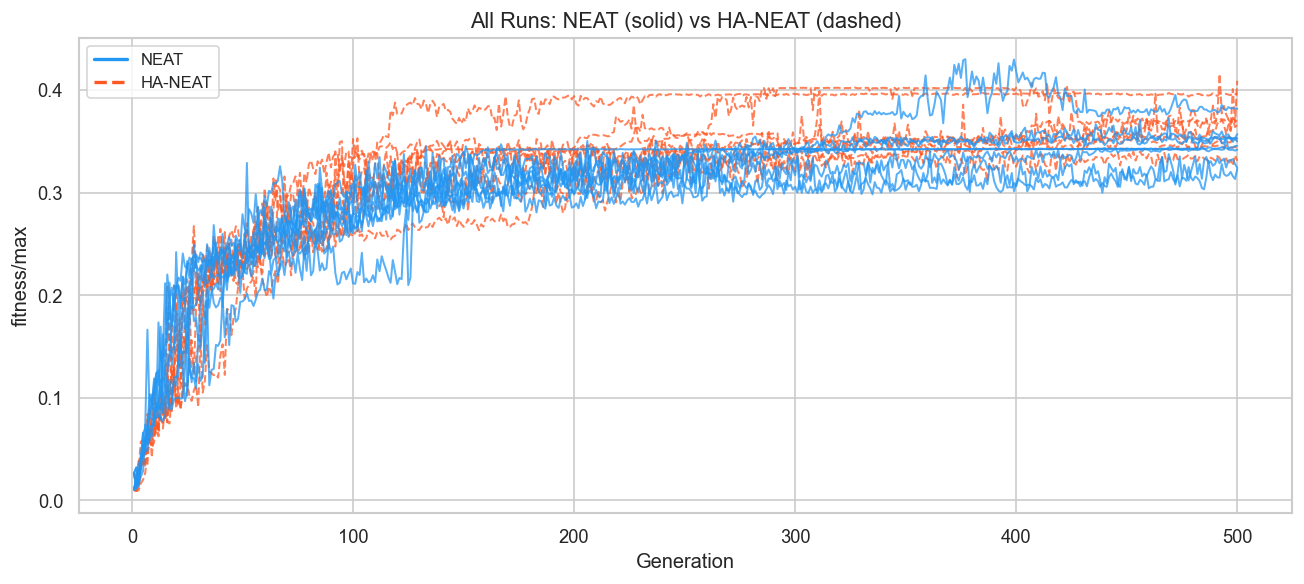

In [5]:
# ── All runs on one plot, coloured by algorithm_type ──────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
algo_palette = {'neat': '#2196F3', 'ha_neat': '#FF5722'}

for label, grp in fit_hist.groupby('label'):
    algo = grp['algorithm'].iloc[0]
    is_ha = algo == 'ha_neat'
    ax.plot(grp['step'], grp['value'],
            lw=1.2, alpha=0.75,
            color=algo_palette[algo],
            linestyle='--' if is_ha else '-',
            label=label)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='#2196F3', lw=2, label='NEAT'),
    Line2D([0],[0], color='#FF5722', lw=2, linestyle='--', label='HA-NEAT'),
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel('Generation')
ax.set_ylabel('fitness/max')
ax.set_title('All Runs: NEAT (solid) vs HA-NEAT (dashed)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 2 · Hyperparameter Grid — Effect on Best Fitness

In [6]:
# ── Summary table: mean ± std best_fitness grouped by (algorithm, pop_size, disjoint) ──
grid = (
    finished
    .groupby(['algorithm', 'pop_size', 'disjoint'])['best_fitness']
    .agg(['mean', 'std', 'max', 'min', 'count'])
    .round(4)
    .reset_index()
)
grid.columns = ['algorithm', 'pop_size', 'disjoint', 'mean', 'std', 'max', 'min', 'n_seeds']
grid = grid.sort_values('mean', ascending=False)
print('Best fitness grouped by (algorithm, pop_size, compatibility_disjoint):')
grid

Best fitness grouped by (algorithm, pop_size, compatibility_disjoint):


,algorithm,pop_size,disjoint,mean,std,max,min,n_seeds
2,ha_neat,2048,0.5,0.4113,0.0060,0.4156,0.4070,2
7,neat,2048,1.0,0.3877,0.0598,0.4300,0.3455,2
3,ha_neat,2048,1.0,0.3736,0.0333,0.3971,0.3501,2
0,ha_neat,1024,0.5,0.3674,0.0079,0.3730,0.3618,2
4,neat,1024,0.5,0.3626,0.0121,0.3711,0.3540,2
6,neat,2048,0.5,0.3555,0.0239,0.3724,0.3386,2
1,ha_neat,1024,1.0,0.3519,0.0027,0.3539,0.3500,2
5,neat,1024,1.0,0.3472,0.0102,0.3544,0.3400,2


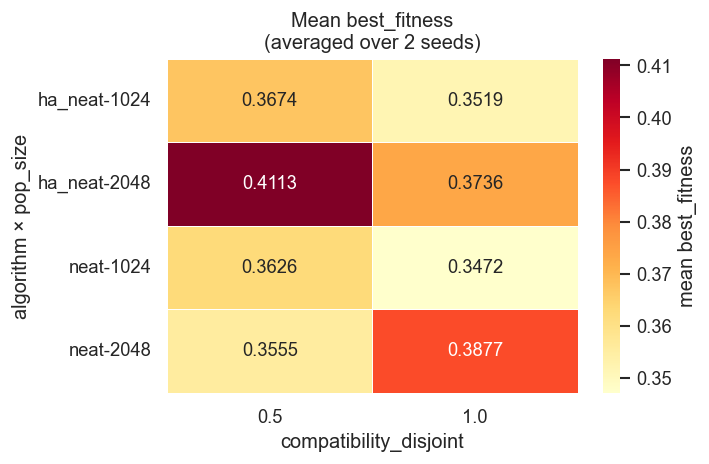

In [7]:
# ── Heatmap: mean best_fitness ─────────────────────────────────────────────────
# Rows = algorithm × pop_size, Cols = compatibility_disjoint
pivot = grid.pivot_table(
    index=['algorithm', 'pop_size'],
    columns='disjoint',
    values='mean'
).round(4)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'mean best_fitness'}
)
ax.set_title('Mean best_fitness\n(averaged over 2 seeds)', fontsize=12)
ax.set_xlabel('compatibility_disjoint')
ax.set_ylabel('algorithm × pop_size')
plt.tight_layout()
plt.show()

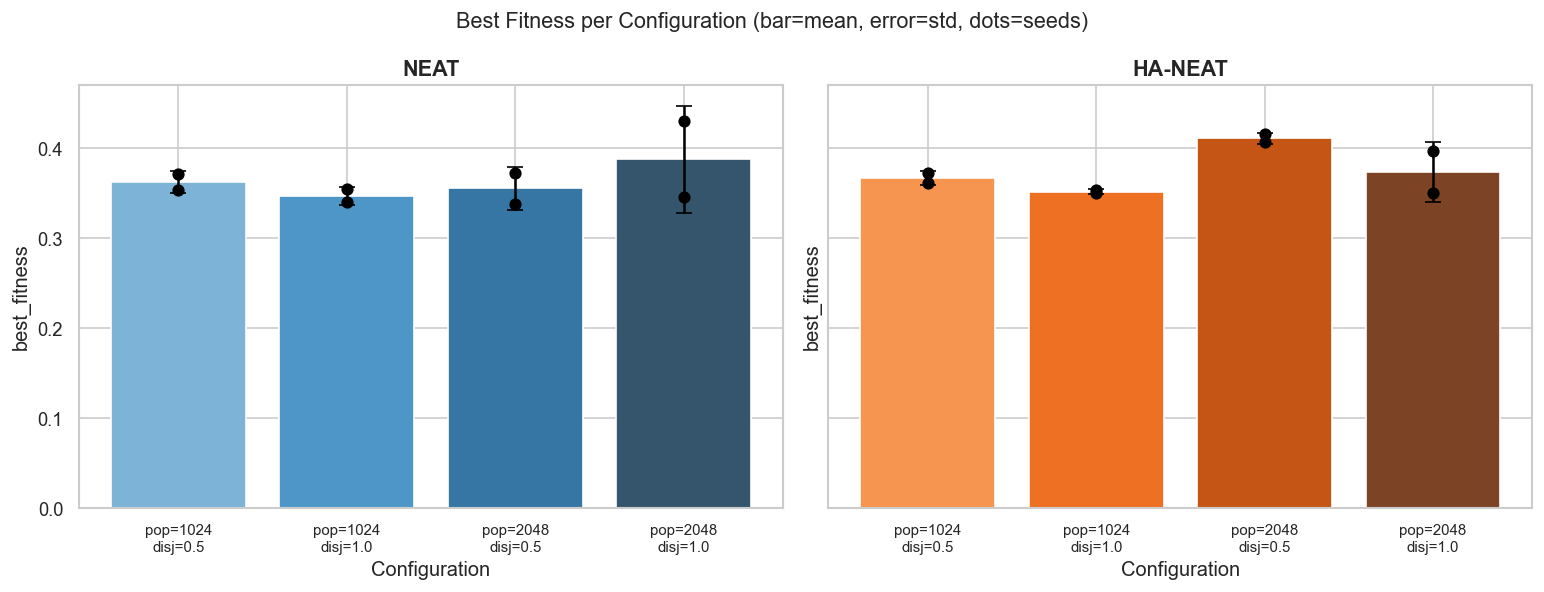

In [8]:
# ── Bar chart: each configuration with error bars (seed variance) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, algo in zip(axes, ['neat', 'ha_neat']):
    sub = finished[finished['algorithm'] == algo].copy()
    sub['config'] = sub.apply(
        lambda r: f"pop={r['pop_size']}\ndisj={r['disjoint']}", axis=1
    )
    agg = sub.groupby('config')['best_fitness'].agg(['mean','std']).reset_index()
    bars = ax.bar(
        agg['config'], agg['mean'],
        yerr=agg['std'], capsize=5,
        color=sns.color_palette('Blues_d', len(agg)) if algo == 'neat'
              else sns.color_palette('Oranges_d', len(agg))
    )
    # Individual seed dots
    for cfg in sub['config'].unique():
        vals = sub[sub['config'] == cfg]['best_fitness'].values
        x_pos = list(agg['config']).index(cfg)
        ax.scatter([x_pos] * len(vals), vals, color='black', zorder=5, s=40)

    ax.set_title(algo.upper().replace('_','-'), fontsize=13, fontweight='bold')
    ax.set_xlabel('Configuration')
    ax.set_ylabel('best_fitness')
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Best Fitness per Configuration (bar=mean, error=std, dots=seeds)', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/nj/p20z0h9x3ssf6ll0_cdhh2yc0000gn/T/ipykernel_46579/2922065973.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=finished, x=col, y='best_fitness', order=order,
/var/folders/nj/p20z0h9x3ssf6ll0_cdhh2yc0000gn/T/ipykernel_46579/2922065973.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=finished, x=col, y='best_fitness', order=order,
/var/folders/nj/p20z0h9x3ssf6ll0_cdhh2yc0000gn/T/ipykernel_46579/2922065973.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=finished, x=col, y='best_fitness', order=order,


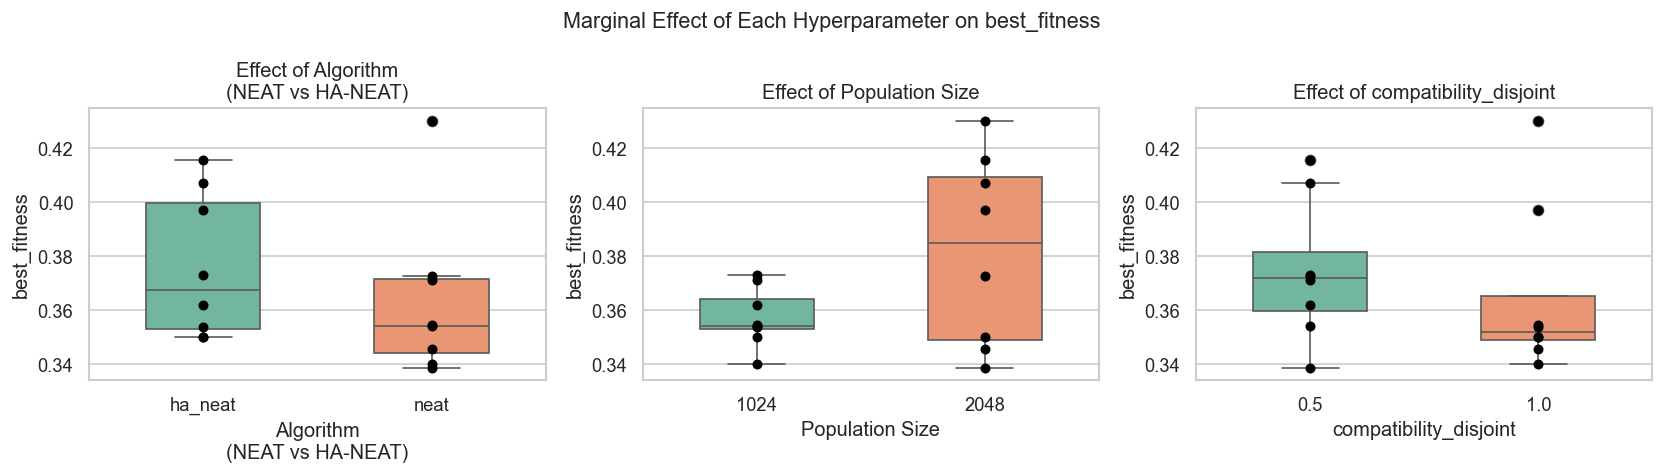

In [9]:
# ── Marginal effects: isolate each hyperparameter ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

factors = [
    ('algorithm',  'Algorithm\n(NEAT vs HA-NEAT)'),
    ('pop_size',   'Population Size'),
    ('disjoint',   'compatibility_disjoint'),
]
for ax, (col, label) in zip(axes, factors):
    order = sorted(finished[col].unique())
    sns.boxplot(data=finished, x=col, y='best_fitness', order=order,
                palette='Set2', ax=ax, width=0.5)
    sns.stripplot(data=finished, x=col, y='best_fitness', order=order,
                  color='black', size=6, ax=ax, jitter=False)
    ax.set_xlabel(label)
    ax.set_ylabel('best_fitness')
    ax.set_title(f'Effect of {label}')

fig.suptitle('Marginal Effect of Each Hyperparameter on best_fitness', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3 · Per-Task Breakdown — Hopper vs Walker2D

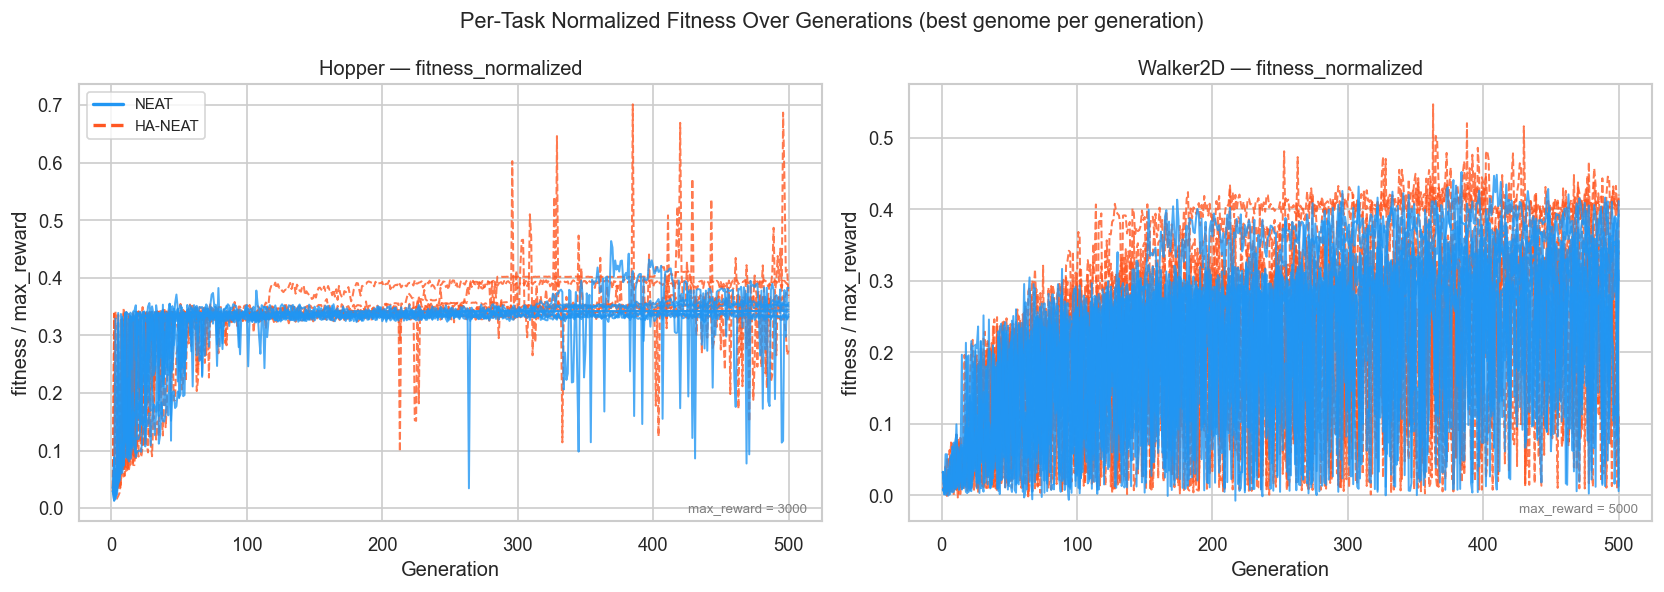

In [10]:
# Load per-task normalized fitness histories
hop_hist = load_all_histories(finished, 'fitness_normalized/hopper')
wal_hist = load_all_histories(finished, 'fitness_normalized/walker2d')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (hist, task) in zip(axes, [(hop_hist, 'Hopper'), (wal_hist, 'Walker2D')]):
    for label, grp in hist.groupby('label'):
        algo = grp['algorithm'].iloc[0]
        ax.plot(grp['step'], grp['value'],
                lw=1.2, alpha=0.8,
                color='#2196F3' if algo == 'neat' else '#FF5722',
                linestyle='-' if algo == 'neat' else '--')
    ax.set_title(f'{task} — fitness_normalized', fontsize=12)
    ax.set_xlabel('Generation')
    ax.set_ylabel('fitness / max_reward')
    if task == 'Hopper':
        ax.annotate('max_reward = 3000', xy=(0.98, 0.02), xycoords='axes fraction',
                    ha='right', fontsize=8, color='grey')
    else:
        ax.annotate('max_reward = 5000', xy=(0.98, 0.02), xycoords='axes fraction',
                    ha='right', fontsize=8, color='grey')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='#2196F3', lw=2, label='NEAT'),
    Line2D([0],[0], color='#FF5722', lw=2, linestyle='--', label='HA-NEAT'),
]
axes[0].legend(handles=legend_elements, fontsize=9)

fig.suptitle('Per-Task Normalized Fitness Over Generations (best genome per generation)', fontsize=13)
plt.tight_layout()
plt.show()

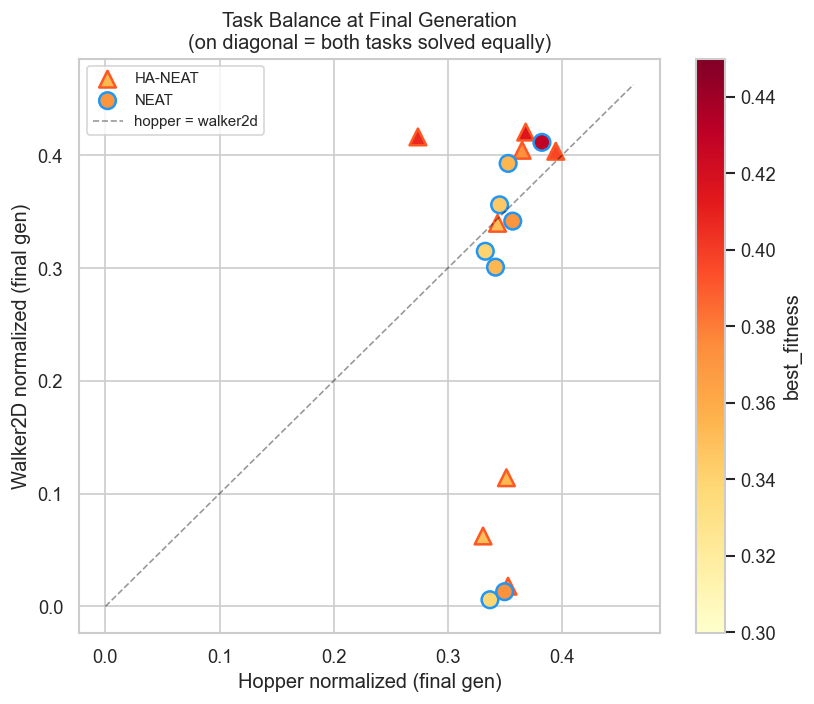

In [11]:
# ── Hopper vs Walker2D scatter at final generation ─────────────────────────────
# For each run: final value of fitness_normalized/hopper vs walker2d
final_hop = hop_hist.groupby('run_id')['value'].last().rename('hopper_norm')
final_wal = wal_hist.groupby('run_id')['value'].last().rename('walker2d_norm')
final_pt = final_hop.to_frame().join(final_wal)
final_pt = final_pt.join(finished.set_index('run_id')[['algorithm','pop_size','disjoint','seed','best_fitness']])

fig, ax = plt.subplots(figsize=(7, 6))
for algo, grp in final_pt.groupby('algorithm'):
    marker = 'o' if algo == 'neat' else '^'
    color  = '#2196F3' if algo == 'neat' else '#FF5722'
    sc = ax.scatter(grp['hopper_norm'], grp['walker2d_norm'],
               c=grp['best_fitness'], cmap='YlOrRd',
               marker=marker, s=100, edgecolors=color, linewidths=1.5,
               label=algo.upper().replace('_','-'), vmin=0.3, vmax=0.45)

plt.colorbar(sc, label='best_fitness')
# Diagonal: if a run is on the diagonal, hopper_norm == walker2d_norm
lims = [0, max(final_pt['hopper_norm'].max(), final_pt['walker2d_norm'].max()) * 1.1]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.4, label='hopper = walker2d')
ax.set_xlabel('Hopper normalized (final gen)')
ax.set_ylabel('Walker2D normalized (final gen)')
ax.set_title('Task Balance at Final Generation\n(on diagonal = both tasks solved equally)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 4 · Structural Complexity — Nodes, Connections, Species

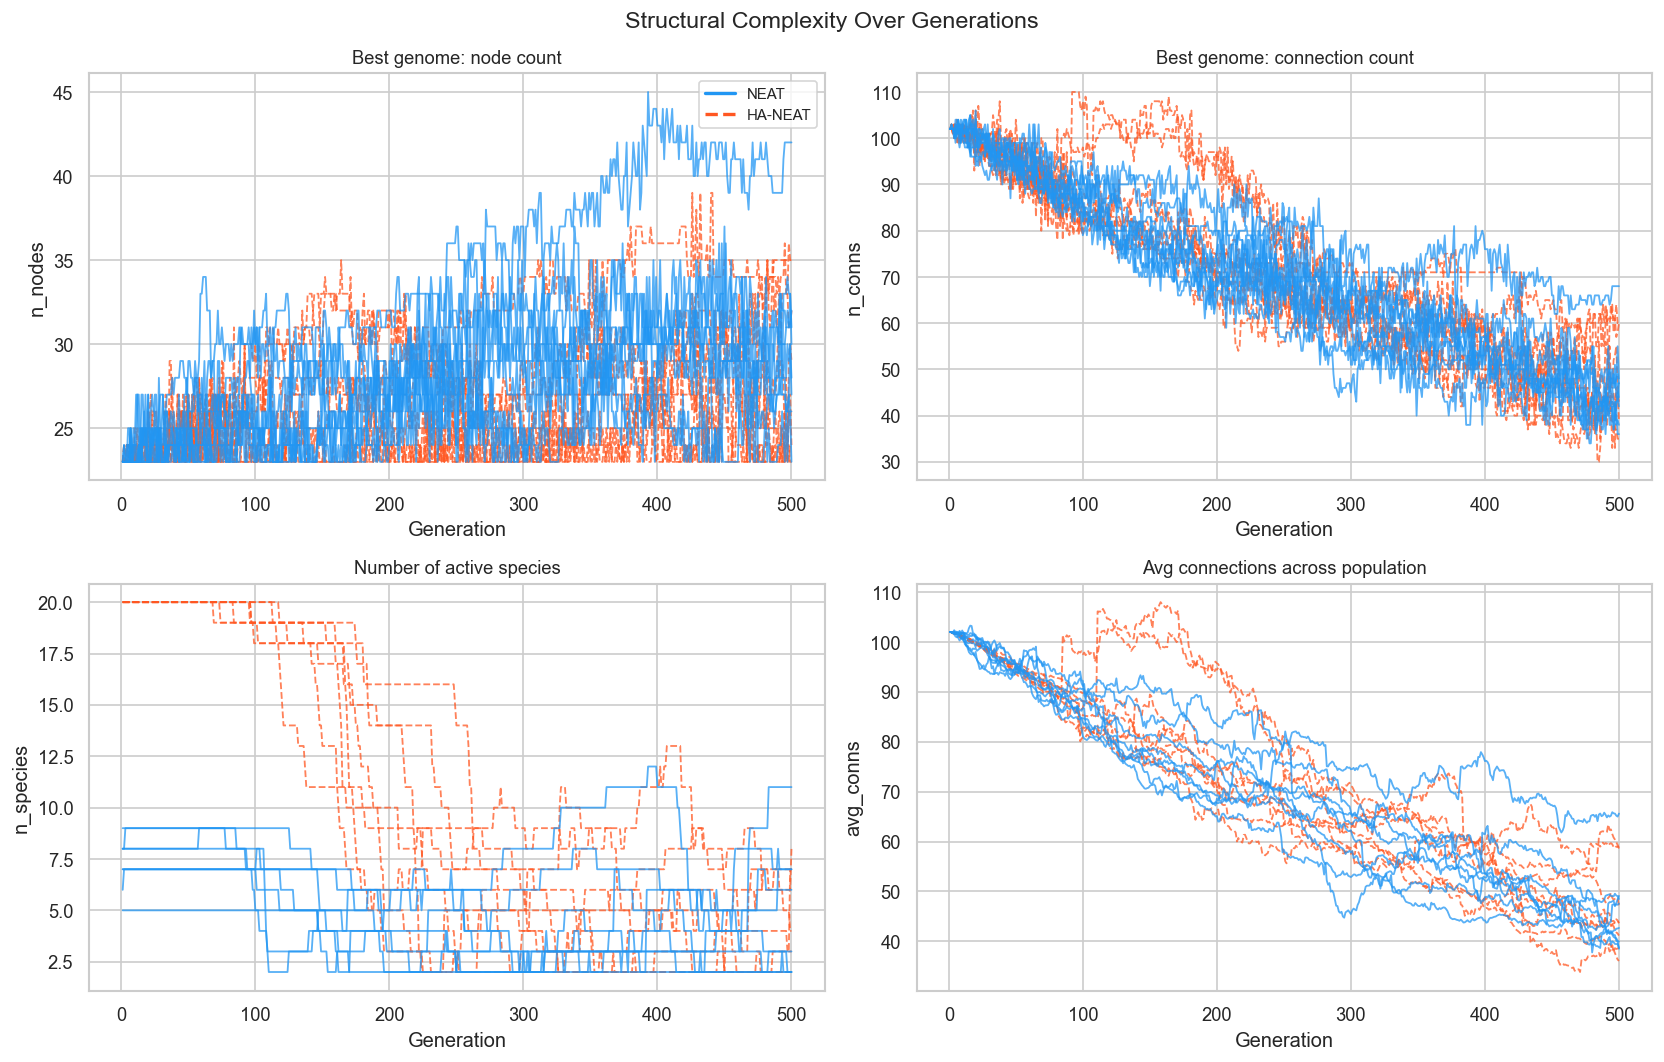

In [12]:
# Load structural metrics
nodes_hist   = load_all_histories(finished, 'neat/best_genome_n_nodes')
conns_hist   = load_all_histories(finished, 'neat/best_genome_n_conns')
species_hist = load_all_histories(finished, 'neat/n_species')
avg_conns_hist = load_all_histories(finished, 'neat/avg_genome_n_conns')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics_to_plot = [
    (nodes_hist,     axes[0,0], 'Best genome: node count',          'n_nodes'),
    (conns_hist,     axes[0,1], 'Best genome: connection count',     'n_conns'),
    (species_hist,   axes[1,0], 'Number of active species',          'n_species'),
    (avg_conns_hist, axes[1,1], 'Avg connections across population', 'avg_conns'),
]

for hist, ax, title, ylabel in metrics_to_plot:
    for label, grp in hist.groupby('label'):
        algo = grp['algorithm'].iloc[0]
        ax.plot(grp['step'], grp['value'],
                lw=1.1, alpha=0.75,
                color='#2196F3' if algo == 'neat' else '#FF5722',
                linestyle='-' if algo == 'neat' else '--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Generation')
    ax.set_ylabel(ylabel)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='#2196F3', lw=2, label='NEAT'),
    Line2D([0],[0], color='#FF5722', lw=2, linestyle='--', label='HA-NEAT'),
]
axes[0,0].legend(handles=legend_elements, fontsize=9)

fig.suptitle('Structural Complexity Over Generations', fontsize=14)
plt.tight_layout()
plt.show()

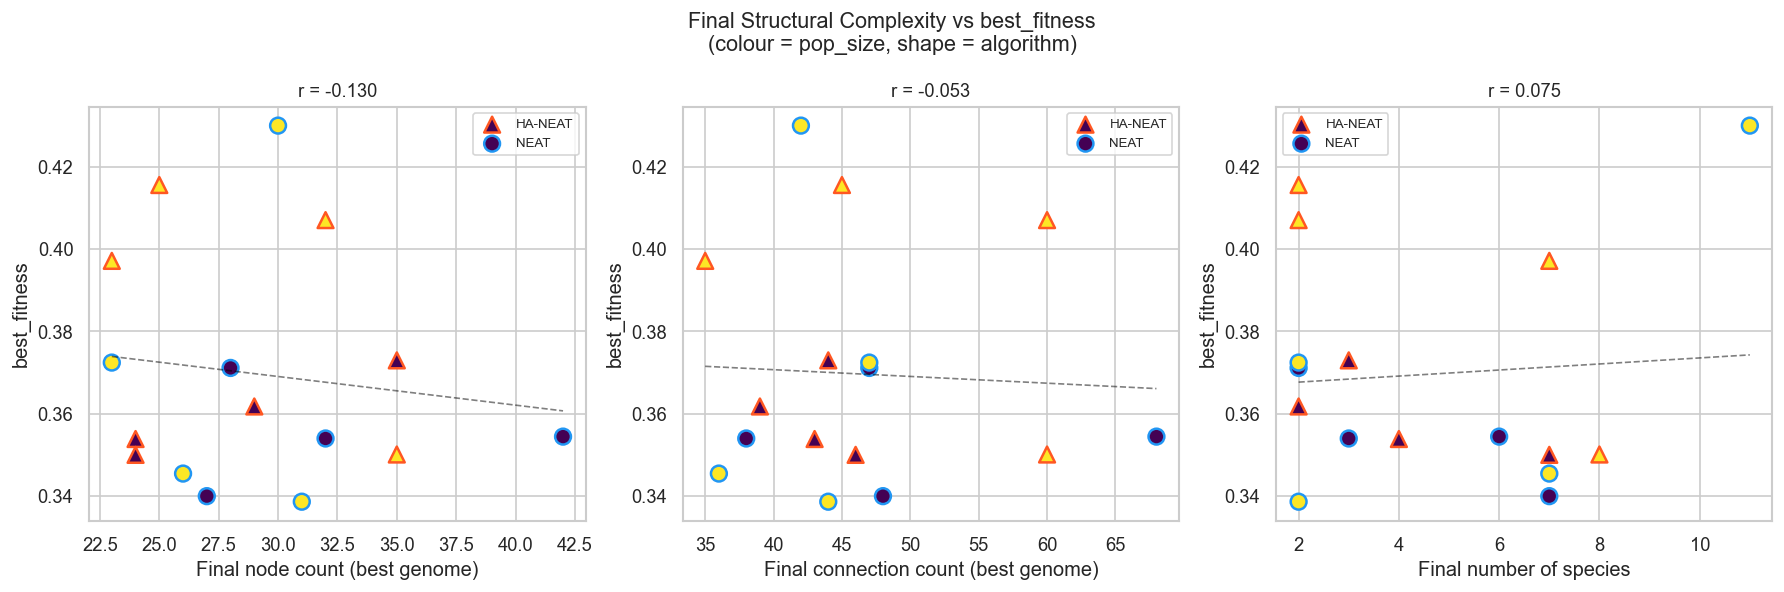

In [13]:
# ── Correlation: final complexity vs best_fitness ──────────────────────────────
def get_final_values(hist_df: pd.DataFrame, col_name: str) -> pd.Series:
    return hist_df.groupby('run_id')['value'].last().rename(col_name)

complexity = (
    get_final_values(nodes_hist, 'final_nodes')
    .to_frame()
    .join(get_final_values(conns_hist, 'final_conns'))
    .join(get_final_values(species_hist, 'final_n_species'))
    .join(finished.set_index('run_id')[['algorithm','pop_size','disjoint','seed','best_fitness']])
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (xcol, xlabel) in zip(axes, [
    ('final_nodes',    'Final node count (best genome)'),
    ('final_conns',    'Final connection count (best genome)'),
    ('final_n_species','Final number of species'),
]):
    for algo, grp in complexity.groupby('algorithm'):
        marker = 'o' if algo == 'neat' else '^'
        color  = '#2196F3' if algo == 'neat' else '#FF5722'
        ax.scatter(grp[xcol], grp['best_fitness'],
                   c=grp['pop_size'], cmap='viridis',
                   marker=marker, s=90, edgecolors=color,
                   linewidths=1.5, label=algo.upper().replace('_','-'),
                   vmin=complexity['pop_size'].min(),
                   vmax=complexity['pop_size'].max())
    # Trend line
    x, y = complexity[xcol].values, complexity['best_fitness'].values
    if len(x) > 2:
        m, b = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 50)
        ax.plot(xline, m * xline + b, 'k--', lw=1, alpha=0.5)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel(xlabel)
    ax.set_ylabel('best_fitness')
    ax.set_title(f'r = {r:.3f}', fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle('Final Structural Complexity vs best_fitness\n(colour = pop_size, shape = algorithm)', fontsize=13)
plt.tight_layout()
plt.show()

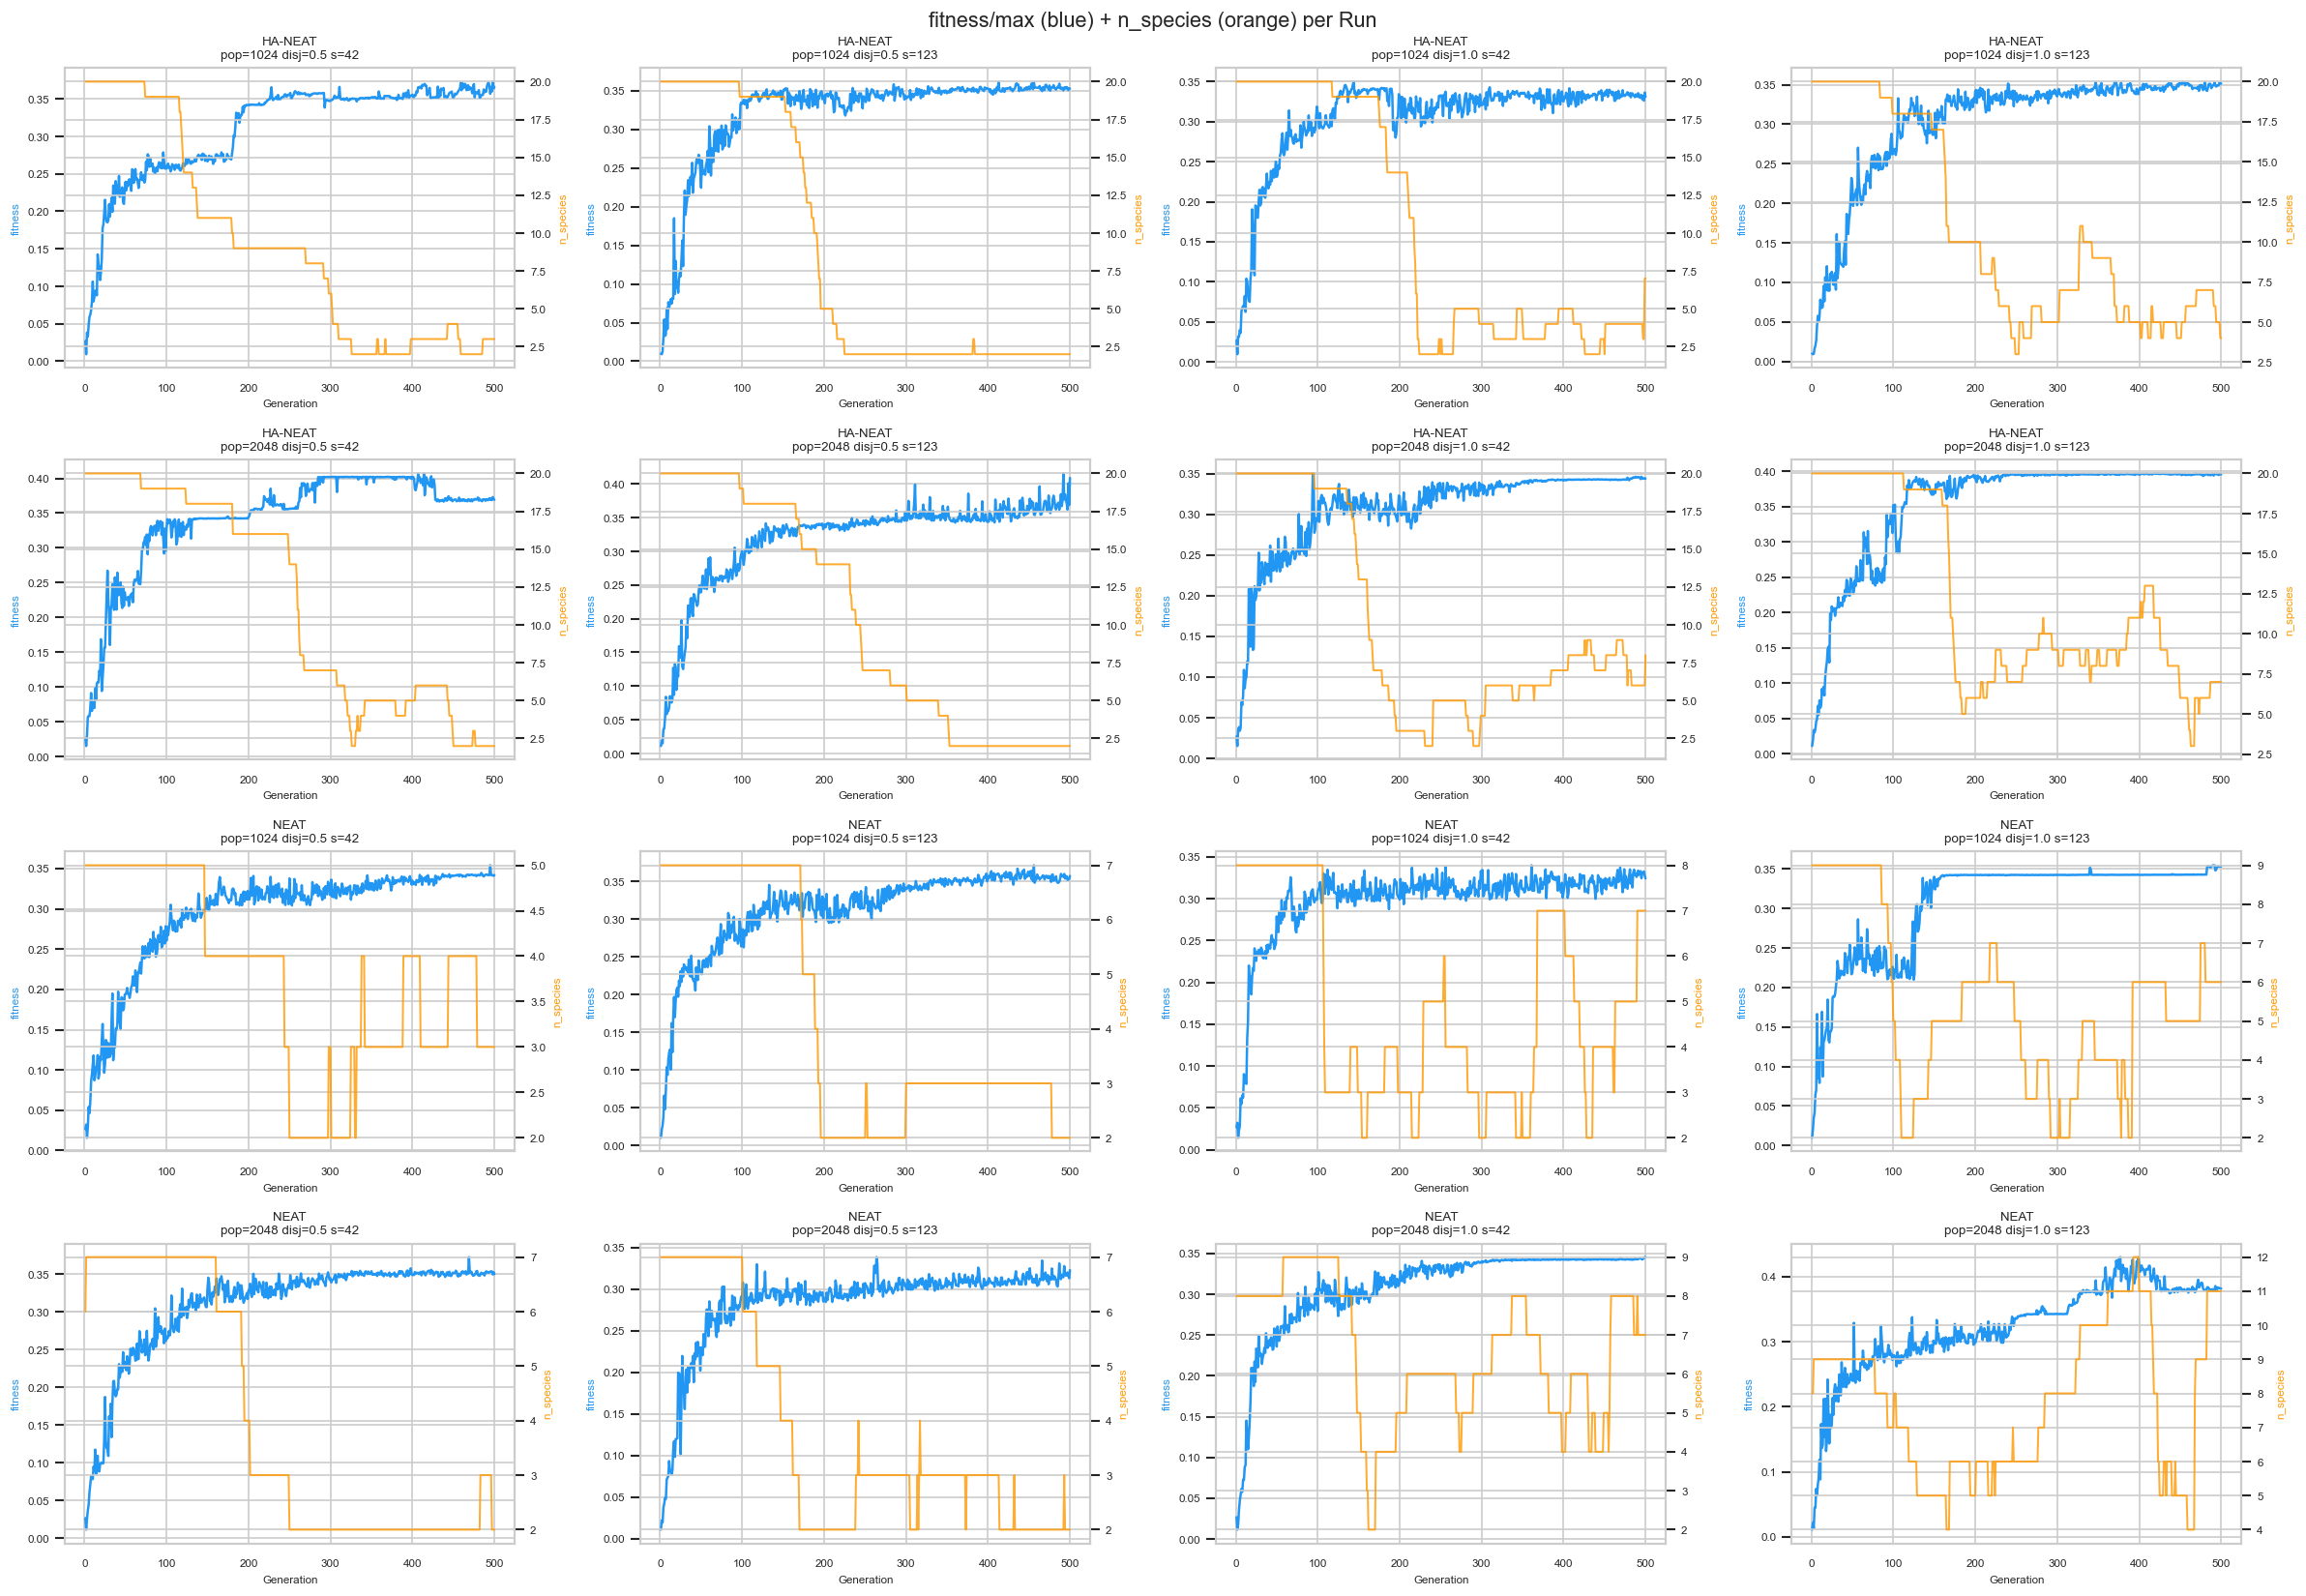

In [14]:
# ── Complexity trajectories aligned to fitness improvement ─────────────────────
# Overlay fitness/max and n_nodes on a dual-axis plot for each run
n_runs = len(finished)
ncols = 4
nrows = (n_runs + ncols - 1) // ncols

fig, all_axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
all_axes_flat = np.array(all_axes).flatten()

for i, (_, row) in enumerate(finished.iterrows()):
    ax1 = all_axes_flat[i]
    ax2 = ax1.twinx()

    fh = load_metric_history(row['run_id'], 'fitness/max')
    nh = load_metric_history(row['run_id'], 'neat/n_species')

    if not fh.empty:
        ax1.plot(fh['step'], fh['value'], color='#2196F3', lw=1.5, label='fitness/max')
    if not nh.empty:
        ax2.plot(nh['step'], nh['value'], color='#FF9800', lw=1.2, alpha=0.8, label='n_species')

    title = (f"{row['algorithm'].upper().replace('_','-')}\n"
             f"pop={row['pop_size']} disj={row['disjoint']} s={row['seed']}")
    ax1.set_title(title, fontsize=8)
    ax1.set_xlabel('Generation', fontsize=7)
    ax1.set_ylabel('fitness', color='#2196F3', fontsize=7)
    ax2.set_ylabel('n_species', color='#FF9800', fontsize=7)
    ax1.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)

# Hide unused axes
for j in range(i + 1, len(all_axes_flat)):
    all_axes_flat[j].set_visible(False)

fig.suptitle('fitness/max (blue) + n_species (orange) per Run', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5 · Stagnation Analysis

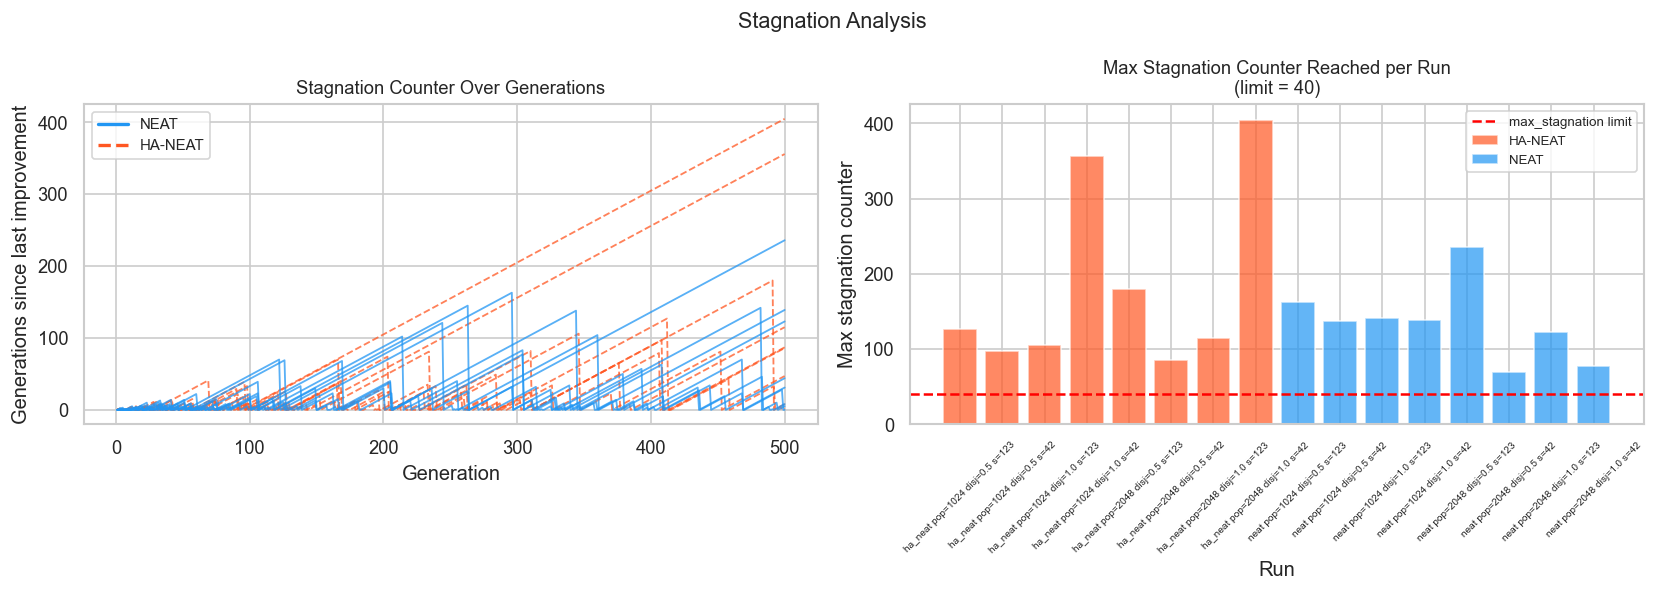

In [15]:
stag_hist = load_all_histories(finished, 'stability/stagnation_counter')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stagnation counter over time
ax = axes[0]
for label, grp in stag_hist.groupby('label'):
    algo = grp['algorithm'].iloc[0]
    ax.plot(grp['step'], grp['value'],
            lw=1.1, alpha=0.75,
            color='#2196F3' if algo == 'neat' else '#FF5722',
            linestyle='-' if algo == 'neat' else '--')
ax.set_title('Stagnation Counter Over Generations', fontsize=11)
ax.set_xlabel('Generation')
ax.set_ylabel('Generations since last improvement')
legend_elements = [
    Line2D([0],[0], color='#2196F3', lw=2, label='NEAT'),
    Line2D([0],[0], color='#FF5722', lw=2, linestyle='--', label='HA-NEAT'),
]
ax.legend(handles=legend_elements, fontsize=9)

# Right: distribution of max stagnation reached per run
ax = axes[1]
max_stag = stag_hist.groupby(['label','algorithm','pop_size','disjoint','seed'])['value'].max().reset_index()
max_stag = max_stag.rename(columns={'value': 'max_stagnation'})
for algo, grp in max_stag.groupby('algorithm'):
    color = '#2196F3' if algo == 'neat' else '#FF5722'
    ax.bar(grp['label'], grp['max_stagnation'], color=color, alpha=0.7,
           label=algo.upper().replace('_','-'))
ax.set_title('Max Stagnation Counter Reached per Run\n(limit = 40)', fontsize=11)
ax.set_xlabel('Run')
ax.set_ylabel('Max stagnation counter')
ax.axhline(40, color='red', linestyle='--', lw=1.5, label='max_stagnation limit')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45, labelsize=6)

fig.suptitle('Stagnation Analysis', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6 · Summary Table

In [16]:
# ── Full comparison table with final per-task metrics ─────────────────────────
final_hop_s = hop_hist.groupby('run_id')['value'].last().rename('hopper_norm_final')
final_wal_s = wal_hist.groupby('run_id')['value'].last().rename('walker2d_norm_final')
final_nodes_s = nodes_hist.groupby('run_id')['value'].last().rename('final_nodes')
final_conns_s = conns_hist.groupby('run_id')['value'].last().rename('final_conns')
final_species_s = species_hist.groupby('run_id')['value'].last().rename('final_n_species')

final_table = (
    finished.set_index('run_id')
    [['algorithm','pop_size','disjoint','seed','best_fitness']]
    .join(final_hop_s)
    .join(final_wal_s)
    .join(final_nodes_s)
    .join(final_conns_s)
    .join(final_species_s)
    .reset_index(drop=True)
    .sort_values('best_fitness', ascending=False)
)

final_table = final_table.round(4)
print('Full summary (sorted by best_fitness):')
final_table

Full summary (sorted by best_fitness):


,algorithm,pop_size,disjoint,seed,best_fitness,hopper_norm_final,walker2d_norm_final,final_nodes,final_conns,final_n_species
15,neat,2048,1.0,123,0.4300,0.3825,0.4116,30.0,42.0,11.0
5,ha_neat,2048,0.5,123,0.4156,0.3683,0.4207,25.0,45.0,2.0
4,ha_neat,2048,0.5,42,0.4070,0.2738,0.4164,32.0,60.0,2.0
7,ha_neat,2048,1.0,123,0.3971,0.3947,0.4037,23.0,35.0,7.0
0,ha_neat,1024,0.5,42,0.3730,0.3652,0.4045,35.0,44.0,3.0
12,neat,2048,0.5,42,0.3724,0.3498,0.0131,23.0,47.0,2.0
9,neat,1024,0.5,123,0.3711,0.3569,0.3417,28.0,47.0,2.0
1,ha_neat,1024,0.5,123,0.3618,0.3528,0.0179,29.0,39.0,2.0
11,neat,1024,1.0,123,0.3544,0.3529,0.3929,42.0,68.0,6.0
8,neat,1024,0.5,42,0.3540,0.3418,0.3009,32.0,38.0,3.0


In [17]:
# ── Key findings summary ───────────────────────────────────────────────────────
print('=== KEY FINDINGS ===')
print()

# 1. Best overall run
best_row = final_table.iloc[0]
print(f'Best run: {best_row["algorithm"]} pop={best_row["pop_size"]} '
      f'disjoint={best_row["disjoint"]} seed={best_row["seed"]}')
print(f'  best_fitness = {best_row["best_fitness"]:.4f}')
print()

# 2. NEAT vs HA-NEAT
neat_mean = finished[finished['algorithm']=='neat']['best_fitness'].mean()
haneat_mean = finished[finished['algorithm']=='ha_neat']['best_fitness'].mean()
print(f'NEAT mean best_fitness:    {neat_mean:.4f}')
print(f'HA-NEAT mean best_fitness: {haneat_mean:.4f}')
print(f'Difference (HA-NEAT - NEAT): {haneat_mean - neat_mean:+.4f}')
print()

# 3. Disjoint effect
d05 = finished[finished['disjoint']==0.5]['best_fitness'].mean()
d10 = finished[finished['disjoint']==1.0]['best_fitness'].mean()
print(f'disjoint=0.5 mean: {d05:.4f}')
print(f'disjoint=1.0 mean: {d10:.4f}')
print(f'Difference (0.5 - 1.0): {d05 - d10:+.4f}')
print()

# 4. Pop size effect (only runs where both sizes exist)
p1024 = finished[finished['pop_size']==1024]['best_fitness'].mean()
p2048_neat = finished[(finished['pop_size']==2048) & (finished['algorithm']=='neat')]['best_fitness'].mean()
print(f'pop=1024 mean: {p1024:.4f}')
print(f'pop=2048 (NEAT only) mean: {p2048_neat:.4f}')
print('Note: HA-NEAT pop=2048 runs not yet finished')

=== KEY FINDINGS ===

Best run: neat pop=2048 disjoint=1.0 seed=123
  best_fitness = 0.4300

NEAT mean best_fitness:    0.3633
HA-NEAT mean best_fitness: 0.3761
Difference (HA-NEAT - NEAT): +0.0128

disjoint=0.5 mean: 0.3742
disjoint=1.0 mean: 0.3651
Difference (0.5 - 1.0): +0.0091

pop=1024 mean: 0.3573
pop=2048 (NEAT only) mean: 0.3716
Note: HA-NEAT pop=2048 runs not yet finished
